# DBSCAN — Density-Based Spatial Clustering of Applications with Noise

## 1. Definition
DBSCAN is an **unsupervised clustering algorithm** that groups together points that are closely packed together (points with many nearby neighbors) and marks points that lie alone in low-density regions as outliers (noise).

Unlike K-Means or Agglomerative Clustering, DBSCAN **does not require specifying the number of clusters** beforehand.

---

## 2. Key Concepts

- **Epsilon (ε):** Radius of the neighborhood around a point.
- **MinPts:** Minimum number of points required to form a dense region.
- **Core Point:** Has at least `MinPts` points within distance ε.
- **Border Point:** Lies within ε of a core point but has fewer than `MinPts` neighbors.
- **Noise Point:** Not a core point or directly reachable from one.

---

## 3. Algorithm Steps
1. **Choose parameters** ε and MinPts.
2. For each unvisited point:
   - Mark it as visited.
   - Retrieve its ε-neighborhood.
   - If it contains at least `MinPts` points, mark it as a **core point** and create a new cluster.
   - Expand the cluster by recursively visiting all neighbors within ε.
   - Points not reachable from any cluster are marked as noise.

---

## 4. Mathematical Definitions
- **Neighborhood of a point** $ p $:

  $$
  N_{\varepsilon}(p) = \{ q \in D \;|\; \text{dist}(p, q) \leq \varepsilon \}
  $$

- **Core point condition**:

  $$
  | N_{\varepsilon}(p) | \geq \text{MinPts}
  $$

---

## 5. Advantages
- Automatically detects the number of clusters.
- Can find clusters of arbitrary shapes.
- Handles noise/outliers well.

## 6. Disadvantages
- Performance depends heavily on ε and MinPts.
- Struggles with clusters of varying densities.

---

<!-- **References:**

- Ester, M., Kriegel, H.-P., Sander, J., Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. KDD.
- scikit-learn documentation: https://scikit-learn.org/stable/modules/clustering.html#dbscan -->


## Import Required Libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Step 2: Generate a Dataset
We'll use a **non-spherical dataset** (`make_moons`) so that DBSCAN's advantage over K-Means is visible.


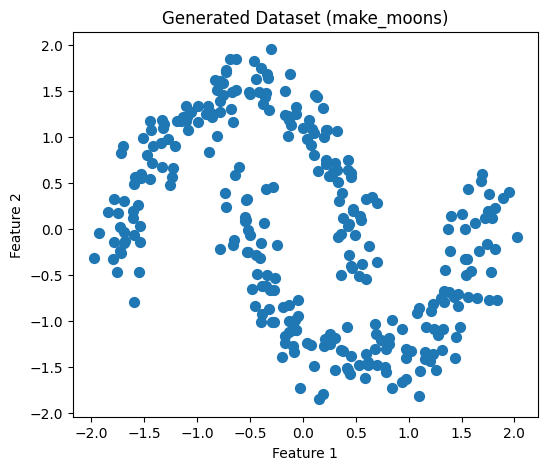

In [11]:
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Standardize features (important for DBSCAN)
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Generated Dataset (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Apply DBSCAN
- We'll set:
  - ε (`eps`) 
  - MinPts (`min_samples`) 

These parameters can be tuned to improve clustering results.


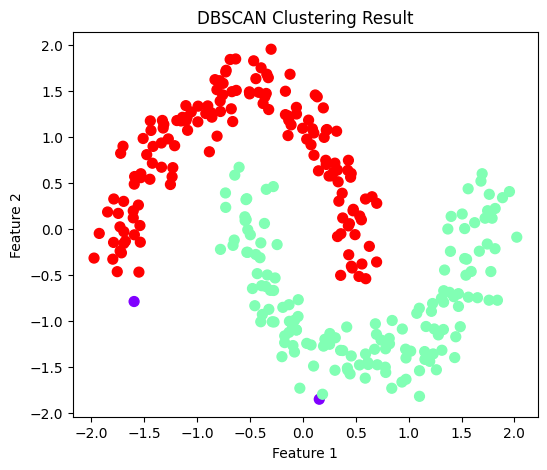

In [12]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=50)
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
